<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/Park_math/%D0%B2%D1%8B%D1%87%D0%BC%D0%B5%D1%824.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N	L∞ ошибка		L2 ошибка
----------------------------------------
10	8.99e-03	3.96e-03
20	2.28e-03	9.89e-04
50	3.67e-04	1.58e-04
100	9.19e-05	3.96e-05

Массивы коэффициентов для метода прогонки перед:
A: ['0.', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '1.0000']
B: ['2.0000', '2.0000', '2.0000', '2.0000', '2.0000', '2.0000', '2.0000', '2.0000', '2.0000', '2.0000', '2.0000']
C: ['1.0000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.5000', '0.']
F: ['0.9627', '3.8706', '8.0696', '11.6339', '13.5110']


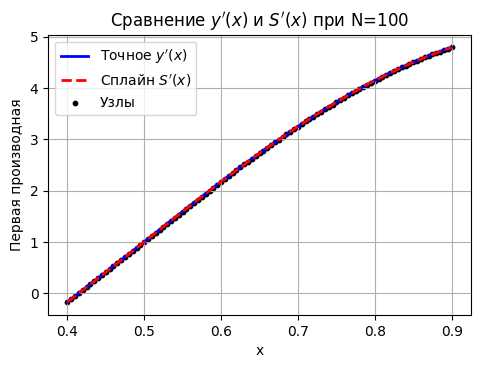

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

def y(x):
    return x**2 - math.sin(math.pi * x)

def y_prime(x):
    return 2*x - math.pi * math.cos(math.pi * x)

def y_double_prime(x):
    return 2 + math.pi**2 * math.sin(math.pi * x)

def solve_tridiagonal_system(A, B, C, F):
    """
    Метод монотонной прогонки
    """
    n = len(B)
    alpha = [0.0] * (n + 1)
    beta = [0.0] * (n + 1)

    if B[0] == 0:
        raise ValueError("0 в первом уравн")
    alpha[1] = -C[0] / B[0]
    beta[1] = F[0] / B[0]

    # прямой ход
    for k in range(1, n-1):
        denom = B[k] + A[k] * alpha[k]
        if abs(denom) < 1e-15:
            raise ValueError(f"0 знаменатель при k={k}")
        alpha[k+1] = -C[k] / denom
        beta[k+1] = (F[k] - A[k] * beta[k]) / denom

    # последнее уравнение
    denom = B[n-1] + A[n-1] * alpha[n-1]
    if abs(denom) < 1e-15:
        raise ValueError("0 знаменатель в послед уравн")
    U = [0.0] * n
    U[n-1] = (F[n-1] - A[n-1] * beta[n-1]) / denom

    # Обратный ход
    for k in range(n-2, -1, -1):
        U[k] = alpha[k+1] * U[k+1] + beta[k+1]

    return U

def build_spline_slopes(x_nodes, y_vals, ypp_a, ypp_b):
    """
    Построение системы для m_i через наклоны.
    Краевые условия 2-го типа.
    """
    n = len(x_nodes) - 1
    h = [x_nodes[i+1] - x_nodes[i] for i in range(n)]

    A = [0.0] * (n+1)  # нижняя диагональ
    B = [0.0] * (n+1)  # главная диагональ
    C = [0.0] * (n+1)  # верхняя диагональ
    F = [0.0] * (n+1)  # правая часть

    # левое краевое условие
    B[0] = 2.0
    C[0] = 1.0
    F[0] = (3.0 / h[0]) * (y_vals[1] - y_vals[0]) - (h[0] / 2.0) * ypp_a

    # Уравнения 1..n-1
    for i in range(1, n):
        mu_i = h[i] / (h[i-1] + h[i])
        lambda_i = h[i-1] / (h[i-1] + h[i])
        A[i] = mu_i
        B[i] = 2.0
        C[i] = lambda_i
        F[i] = 3.0 * (
            lambda_i * (y_vals[i+1] - y_vals[i]) / h[i] +
            mu_i * (y_vals[i] - y_vals[i-1]) / h[i-1]
        )

    # правое краевое условие
    A[n] = 1.0
    B[n] = 2.0
    F[n] = (h[n-1] / 2.0) * ypp_b + (3.0 / h[n-1]) * (y_vals[n] - y_vals[n-1])

    return solve_tridiagonal_system(A, B, C, F)

def evaluate_spline_derivative(x_point, x_nodes, y_vals, m_slopes):
    """
    Вычисление S'(x) — первой производной сплайна в точке x_point.
    """
    n = len(x_nodes) - 1
    i = 0
    for j in range(n):
        if x_nodes[j] <= x_point <= x_nodes[j+1]:
            i = j
            break
    if i == n:
        i = n - 1

    h_i = x_nodes[i+1] - x_nodes[i]
    t = x_point - x_nodes[i]

    # Коэффициенты a_i и b_i
    b_i = (12.0 / (h_i*h_i)) * (
        (m_slopes[i+1] + m_slopes[i]) / 2.0 -
        (y_vals[i+1] - y_vals[i]) / h_i
    )
    a_i = (6.0 / h_i) * (
        (y_vals[i+1] - y_vals[i]) / h_i -
        (m_slopes[i+1] + 2*m_slopes[i]) / 3.0
    )

    return m_slopes[i] + 2*a_i*t + 3*b_i*t*t

N_values = [10, 20, 50, 100]
a, b = 0.4, 0.9
errors_Linf = []  # Максимальная ошибка
errors_L2 = []   # Среднеквадратичная ошибка

# Точки для оценки ошибки
X_dense = np.linspace(a, b, 1000)
Y_exact = np.array([y_prime(x) for x in X_dense])

for N in N_values:
    # Узлы сплайна
    x_nodes = np.linspace(a, b, N+1)
    y_vals = [y(x) for x in x_nodes]
    ypp_a = y_double_prime(a)
    ypp_b = y_double_prime(b)

    # Построение наклонов
    m_slopes = build_spline_slopes(x_nodes, y_vals, ypp_a, ypp_b)

    # Вычисление приближенной производной на плотной сетке
    Y_spline = [evaluate_spline_derivative(x, x_nodes, y_vals, m_slopes) for x in X_dense]

    # Ошибки
    errors = np.array(Y_spline) - np.array(Y_exact)
    Linf_error = np.max(np.abs(errors))
    L2_error = np.sqrt(np.mean(errors**2))

    errors_Linf.append(Linf_error)
    errors_L2.append(L2_error)

# Вывод таблицы ошибок
print("N\tL∞ ошибка\t\tL2 ошибка")
print("-" * 40)
for N, e_inf, e2 in zip(N_values, errors_Linf, errors_L2):
    print(f"{N}\t{e_inf:.2e}\t{e2:.2e}")

print("\nМассивы коэффициентов для метода прогонки перед:")
print(f"A: {[f'{val:.4f}' if val != 0 else '0.' for val in A]}")
print(f"B: {[f'{val:.4f}' for val in B]}")
print(f"C: {[f'{val:.4f}' if val != 0 else '0.' for val in C]}")
print(f"F: {[f'{val:.4f}' for val in F]}")

# Сравнение производных сплайна и функции
plt.figure(figsize=(12, 8))

N_plot = N_values[-1]
x_nodes_plot = np.linspace(a, b, N_plot+1)
y_vals_plot = [y(x) for x in x_nodes_plot]
ypp_a_plot = y_double_prime(a)
ypp_b_plot = y_double_prime(b)
m_slopes_plot = build_spline_slopes(x_nodes_plot, y_vals_plot, ypp_a_plot, ypp_b_plot)
Y_spline_plot = [evaluate_spline_derivative(x, x_nodes_plot, y_vals_plot, m_slopes_plot) for x in X_dense]

plt.subplot(2, 2, 1)
plt.plot(X_dense, Y_exact, label="Точное $y'(x)$", color='blue', linewidth=2)
plt.plot(X_dense, Y_spline_plot, '--', label="Сплайн $S'(x)$", color='red', linewidth=2)
plt.scatter(x_nodes_plot, [evaluate_spline_derivative(x, x_nodes_plot, y_vals_plot, m_slopes_plot) for x in x_nodes_plot],
            color='black', s=10, label="Узлы")
plt.title(f"Сравнение $y'(x)$ и $S'(x)$ при N={N_plot}")
plt.xlabel("x")
plt.ylabel("Первая производная")
plt.legend()
plt.grid(True)